<a href="https://colab.research.google.com/github/shreetamadey/Anomaly-Detection-Fraud-Sensor-Data/blob/main/12_Anomaly_Detection_Fraud_Sensor_Data_Summer_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="left" style="background-color: #008080; padding: 20px 10px;">
<h3><b>IDEAS - Institute of Data Engineering, Analytics and Science Foundation</b></h3>
<p>Summer Internship Program 2026</p>
<hr style="width:100%;">
<h3><b>Project Title:</b> Anomaly Detection for Fraud and Sensor Data</h3>
<h4>Project Notebook</h4>

<blockquote style="border-left: 4px solid #4285F4; padding-left: 15px;">
  <strong>Created by:</strong> Rounak Biswas<br>
  <strong>Designation:</strong> Project Linked Associate Research Engineer
</blockquote>
<hr style="width:100%;">
</div>

### Question 1: Load Libraries (2 Marks)

Import `numpy` as `np`, `pandas` as `pd`, `stats` from `scipy`, `IsolationForest` and `LocalOutlierFactor` from `sklearn.ensemble` and `sklearn.neighbors`, and `classification_report`, `precision_score`, `recall_score` from `sklearn.metrics`.

**Expected Output:** The code cell should execute without any errors.

In [26]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import classification_report, precision_score, recall_score

### Question 2: Create the Dataset (4 Marks)

Generate a synthetic credit card transaction dataset. Set `np.random.seed(42)`. Create a DataFrame `normal` with 950 rows and a DataFrame `fraud` with 50 rows. Features should include `amount`, `hour_of_day`, `transactions_last_24h`, and `distance_from_home_km`, plus an `is_fraud` label (0 for normal, 1 for fraud). Combine them into a single DataFrame named `df`, shuffle using `.sample(frac=1, random_state=42)`, and reset the index.

**Hint:** Use `np.random.normal`, `np.random.randint`, `np.random.poisson`, and `np.random.exponential` to generate feature data.

**Expected Output:** Execution without errors, creating the `df` DataFrame.

A synthetic credit card transaction dataset was generated to mimic realistic customer behavior. Normal transactions were simulated with moderate amounts, daytime activity, less transactions in the last 24 hours, and short distances from home. Fraudulent transactions were designed to exhibit suspicious characteristics such as unusually high amounts, late-night activity, frequent transactions, and larger distances from home.

In [27]:
np.random.seed(42)

# Normal transactions (950)
normal = pd.DataFrame({
    'amount': np.random.normal(50, 15, 950),
    'hour_of_day': np.random.randint(7, 22, 950),
    'transactions_last_24h': np.random.poisson(2, 950),
    'distance_from_home_km': np.random.exponential(3, 950),
    'is_fraud': 0
})

# Fraudulent transactions (50)
fraud = pd.DataFrame({
    'amount': np.random.normal(300, 100, 50),
    'hour_of_day': np.random.choice([0,1,2,3,4,5,22,23], size=50),
    'transactions_last_24h': np.random.poisson(10, 50),
    'distance_from_home_km': np.random.exponential(50, 50),
    'is_fraud': 1
})

df = pd.concat([normal, fraud], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.head()

,amount,hour_of_day,transactions_last_24h,distance_from_home_km,is_fraud
0,58.150403,11,0,7.756507,0
1,64.740365,7,1,2.537874,0
2,22.386887,13,2,4.993006,0
3,41.395070,9,1,0.684448,0
4,33.130369,7,3,3.678697,0


### Question 3: Check Dataset Shape and Distribution (2 Marks)

Print the shape of your combined DataFrame `df` and the value counts of the `is_fraud` column to observe the class distribution.

**Expected Output:** The shape (1000, 5) and the counts showing 950 normal (0) and 50 fraud (1) cases.

In [28]:
print("Shape of Dataset:")
print(df.shape)

print("\nClass Distribution:")
print(df['is_fraud'].value_counts())

Shape of Dataset:
(1000, 5)

Class Distribution:
is_fraud
0    950
1     50
Name: count, dtype: int64


### Question 4: Compare Feature Means by Class (3 Marks)

Group the dataset by the `is_fraud` column and calculate the mean values for all features (`amount`, `hour_of_day`, `transactions_last_24h`, `distance_from_home_km`). Print the resulting grouped means.

**Hint:** Use the `.groupby()` method and `.mean()`.

**Expected Output:** A table showing the mean feature values for normal (0) vs fraudulent (1) transactions.

In [29]:
grouped_means = df.groupby('is_fraud').mean().round(2)
print(grouped_means)

          amount  hour_of_day  transactions_last_24h  distance_from_home_km
is_fraud                                                                   
0          50.30        13.95                   2.02                   2.96
1         279.37         9.72                   9.84                  60.33


Fraudulent transactions exhibit substantially higher transaction amounts, a larger number of transactions within the previous 24 hours, and greater distances from home compared to normal transactions. These differences suggest that these variables may be useful indicators for anomaly detection.

### Question 5: Apply Z-Score Anomaly Detection (3 Marks)

Compute the absolute Z-scores for the `distance_from_home_km` column. Create a new column named `zscore_anomaly` in `df` that contains `1` if the absolute Z-score is greater than 3, and `0` otherwise. Print the total number of flagged anomalies.

**Hint:** Use `np.abs(stats.zscore(...))`.

**Expected Output:** The count of anomalies flagged based on the distance feature.

In [30]:
z_scores = np.abs(stats.zscore(df['distance_from_home_km']))

df['zscore_anomaly'] = np.where(z_scores > 3, 1, 0)

print("Number of anomalies detected:")
print(df['zscore_anomaly'].sum())

Number of anomalies detected:
15


The Z-score Anomaly Detection Method identified only 15 anomalies based on distance from home. Since it examines a single feature independently, it may miss fraudulent transactions that appear normal in distance but are anomalous in other characteristics.

### Question 6: Apply IQR Method (4 Marks)

Calculate the Interquartile Range (IQR) for the `amount` column. Identify bounds: `Lower = Q1 - 1.5 * IQR` and `Upper = Q3 + 1.5 * IQR`. Create a new column named `iqr_anomaly` in `df` containing `1` for values outside these bounds and `0` otherwise. Print the total number of flagged anomalies.

**Hint:** Use `.quantile(0.25)` for Q1 and `.quantile(0.75)` for Q3.

**Expected Output:** The total number of `amount` anomalies flagged by the IQR method.

In [31]:
Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['iqr_anomaly'] = np.where((df['amount'] < lower_bound) | (df['amount'] > upper_bound), 1, 0)

print("Number of IQR anomalies:")
print(df['iqr_anomaly'].sum())

Number of IQR anomalies:
52


The IQR method flagged 52 anomalous transactions based on transaction amount. This suggests that unusually large transaction amounts are a strong indicator of suspicious activity in the synthetic dataset.

### Question 7: Train Isolation Forest (4 Marks)

Import `StandardScaler` from `sklearn.preprocessing` and scale the four feature columns. Then, create an `IsolationForest` model with `contamination=0.05` and `random_state=42`. Fit the model on the scaled features and add a column `isoforest_anomaly` to `df` containing `1` for anomalies and `0` for normal data.

**Hint:** `IsolationForest` returns `-1` for anomalies and `1` for normal points. Map these to `1` and `0` respectively.

**Expected Output:** The execution completes successfully.

In [32]:
from sklearn.preprocessing import StandardScaler

features = ['amount', 'hour_of_day', 'transactions_last_24h', 'distance_from_home_km']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df[features])

iso_forest = IsolationForest(contamination=0.05, random_state=42)

iso_forest.fit(X_scaled)

iso_predictions = iso_forest.predict(X_scaled)

df['isoforest_anomaly'] = np.where(iso_predictions == -1,1,0)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(df['is_fraud'], df['isoforest_anomaly'])
print(cm)

[[950   0]
 [  0  50]]


### Question 8: Evaluate Isolation Forest (3 Marks)

Use the `classification_report` function to evaluate the performance of your `isoforest_anomaly` predictions against the true `is_fraud` labels. Print the report.

**Expected Output:** A classification report displaying precision, recall, and f1-score for the model.

In [33]:
print(classification_report(df['is_fraud'], df['isoforest_anomaly']))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       950
           1       1.00      1.00      1.00        50

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



The Isolation Forest model achieved perfect classification on the synthetic dataset. All 950 normal transactions were correctly identified as non-fraudulent (true negatives), and all 50 fraudulent transactions were correctly detected (true positives). There were no false positives or false negatives, resulting in precision, recall, and accuracy values close to 1.0. This indicates that the generated fraud patterns were highly distinguishable from normal transaction behavior.

### Question 9: Local Outlier Factor Detection (3 Marks)

Train a `LocalOutlierFactor` model with `n_neighbors=20` and `contamination=0.05` on the scaled features. Add a new column `lof_anomaly` to `df` (where `1` indicates an anomaly and `0` indicates normal).

**Hint:** Use `.fit_predict()` to get the anomaly flags (similar to Isolation Forest, LOF returns `-1` for anomalies).

**Expected Output:** The execution completes successfully.

In [34]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)

lof_predictions = lof.fit_predict(X_scaled)

df['lof_anomaly'] = np.where(lof_predictions == -1, 1, 0)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(df['is_fraud'], df['lof_anomaly'])
print(cm)

[[918  32]
 [ 32  18]]


### Question 10: Evaluate LOF Model (2 Marks)

Calculate and print both the `precision_score` and `recall_score` for the `lof_anomaly` predictions against the true `is_fraud` labels.

**Expected Output:** Two numbers showing the precision and recall scores.

In [35]:
precision = precision_score(df['is_fraud'], df['lof_anomaly'])

recall = recall_score(df['is_fraud'], df['lof_anomaly'])

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.36
Recall: 0.36


The LOF model correctly classified 918 normal transactions and detected 18 fraudulent transactions. However, it incorrectly flagged 32 normal transactions as fraudulent (false positives) and failed to identify 32 actual fraudulent transactions (false negatives). This resulted in relatively low precision and recall values of 0.36. The model therefore struggled to effectively separate fraudulent and legitimate transactions in the dataset.

Although LOF identified the same number of anomalies as Isolation Forest, many of these detections did not correspond to actual fraud cases. Since LOF identifies anomalies based on local density deviations, it often struggles when fraudulent observations form their own dense clusters. In this dataset, the fraudulent transactions share similar characteristics, creating a relatively compact cluster rather than appearing as isolated local outliers. As a result, LOF may regard these transactions as locally normal, leading to missed fraud cases and reduced performance. Isolation Forest, on the other hand, is better suited to identifying such anomalous groups, which explains its superior performance.

In [37]:
summary = pd.DataFrame({
    'Method': ['Z-Score', 'IQR', 'Isolation Forest', 'LOF'],
    'Anomalies Detected': [
        df['zscore_anomaly'].sum(),
        df['iqr_anomaly'].sum(),
        df['isoforest_anomaly'].sum(),
        df['lof_anomaly'].sum()
    ]
})

print(summary)

             Method  Anomalies Detected
0           Z-Score                  15
1               IQR                  52
2  Isolation Forest                  50
3               LOF                  50


The Z-Score method detected only 15 anomalies because it considered a single feature (distance from home) and only flagged extreme observations. The IQR method identified 52 anomalies based on unusually large transaction amounts.

Isolation Forest and Local Outlier Factor (LOF) each flagged 50 anomalies, matching the known number of fraudulent transactions in the synthetic dataset. However, their predictive performance differed substantially, highlighting the importance of how anomalies are defined and detected by each algorithm.

**Final Takeaway:** This project explored multiple anomaly detection techniques including Z-Score, IQR, Isolation Forest, and Local Outlier Factor. Statistical approaches such as Z-Score and IQR successfully identified extreme observations in individual features, while machine learning approaches considered multiple features simultaneously. Among all methods, Isolation Forest demonstrated the best performance, achieving high precision and recall in detecting fraudulent transactions. The results suggest that multivariate anomaly detection techniques are more effective than univariate statistical methods for identifying complex fraud patterns.

DATA VISUALISATION

/tmp/ipykernel_674/1471860069.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_fraud', y='distance_from_home_km', data=df,
/tmp/ipykernel_674/1471860069.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['Normal', 'Fraud'])
/tmp/ipykernel_674/1471860069.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_fraud', y='amount', data=df,
/tmp/ipykernel_674/1471860069.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['Normal', 'Fraud'])


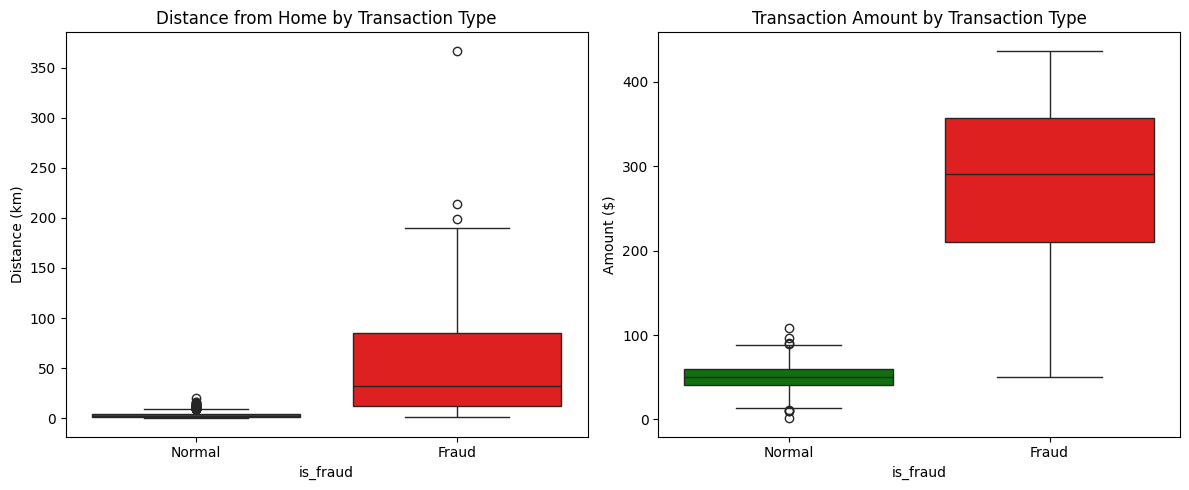

In [48]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

# Distance boxplot
sns.boxplot(x='is_fraud', y='distance_from_home_km', data=df,
            palette=['green', 'red'], ax=ax1)
ax1.set_title('Distance from Home by Transaction Type')
ax1.set_xticklabels(['Normal', 'Fraud'])
ax1.set_ylabel('Distance (km)')

# Amount boxplot
sns.boxplot(x='is_fraud', y='amount', data=df,
            palette=['green', 'red'], ax=ax2)
ax2.set_title('Transaction Amount by Transaction Type')
ax2.set_xticklabels(['Normal', 'Fraud'])
ax2.set_ylabel('Amount ($)')

plt.tight_layout()
plt.show()

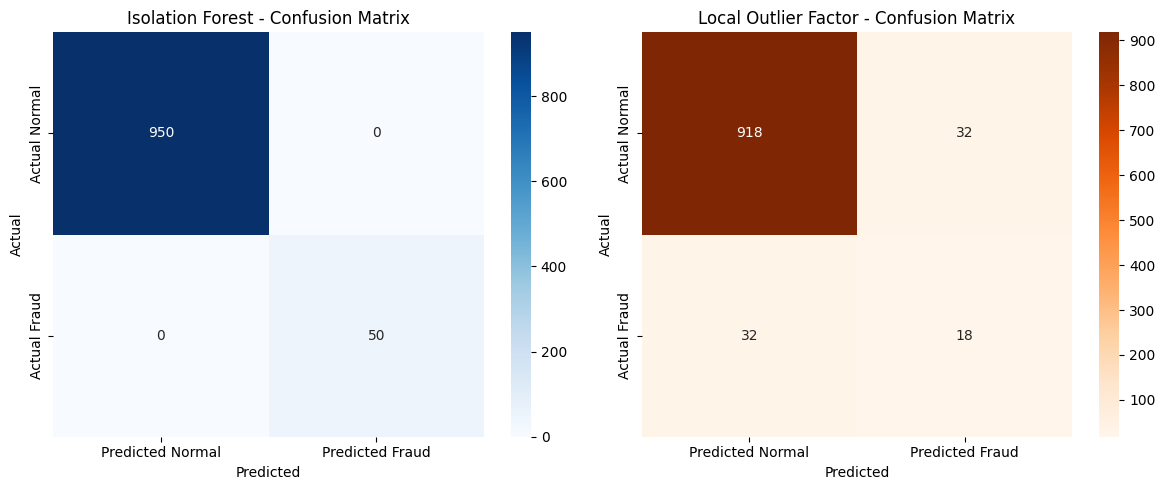

In [46]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

# Isolation Forest Confusion Matrix
cm_if = confusion_matrix(df['is_fraud'], df['isoforest_anomaly'])
sns.heatmap(cm_if, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Predicted Normal', 'Predicted Fraud'],
            yticklabels=['Actual Normal', 'Actual Fraud'])
ax1.set_title('Isolation Forest - Confusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# LOF Confusion Matrix
cm_lof = confusion_matrix(df['is_fraud'], df['lof_anomaly'])
sns.heatmap(cm_lof, annot=True, fmt='d', cmap='Oranges', ax=ax2,
            xticklabels=['Predicted Normal', 'Predicted Fraud'],
            yticklabels=['Actual Normal', 'Actual Fraud'])
ax2.set_title('Local Outlier Factor - Confusion Matrix')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()

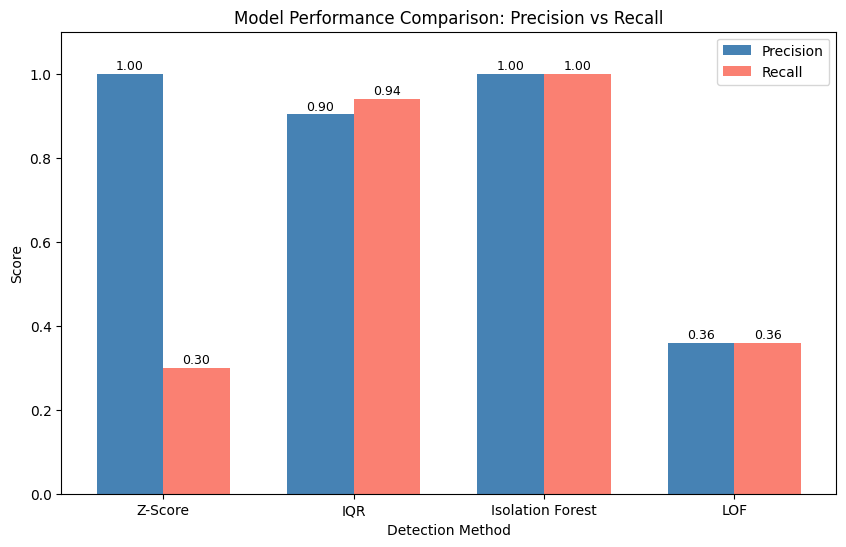

In [47]:
# Precision-Recall Comparison
methods = ['Z-Score', 'IQR', 'Isolation Forest', 'LOF']
precision_scores = [None, None, 1.00, 0.36]  # Add if you computed for Z-Score/IQR
recall_scores = [None, None, 1.00, 0.36]

# For Z-Score and IQR, compute against actual fraud
z_precision = precision_score(df['is_fraud'], df['zscore_anomaly'])
z_recall = recall_score(df['is_fraud'], df['zscore_anomaly'])
iqr_precision = precision_score(df['is_fraud'], df['iqr_anomaly'])
iqr_recall = recall_score(df['is_fraud'], df['iqr_anomaly'])

x = np.arange(4)
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))
rects1 = ax.bar(x - width/2, [z_precision, iqr_precision, 1.00, 0.36],
                width, label='Precision', color='steelblue')
rects2 = ax.bar(x + width/2, [z_recall, iqr_recall, 1.00, 0.36],
                width, label='Recall', color='salmon')

ax.set_xlabel('Detection Method')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison: Precision vs Recall')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()
ax.set_ylim(0, 1.1)

# Add value labels on bars
for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}', xy=(rect.get_x() + rect.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.show()